# Homework 3: SPAMBASE Classification


## Imports and Dataset Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)


In [2]:
from pathlib import Path

HW3_DIR = Path('/Users/seanblundin/Documents/code/ml1-hw3')

feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(',
    'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total'
]

data = pd.read_csv(HW3_DIR / 'spambase.data', header=None)
data.columns = feature_names + ['spam']

X = data[feature_names]
y = data['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)


Training set shape: (3450, 57)
Testing set shape: (1151, 57)


## Problem 1: Logistic Regression

In [3]:
# Scale the data for logistic regression
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)

# Train the logistic regression model
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_lr, y_train)

# Predictions on the testing set
y_pred_lr = log_reg.predict(X_test_lr)
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]


In [4]:
# 1.1 Confusion matrix and evaluation metrics
cm = confusion_matrix(y_test, y_pred_lr)
accuracy = accuracy_score(y_test, y_pred_lr)
error = 1 - accuracy
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print('Confusion Matrix:')
print(cm)
print('\nAccuracy:', accuracy)
print('Error:', error)
print('Precision:', precision)
print('Recall:', recall)
print('F1 score:', f1)


Confusion Matrix:
[[667  30]
 [ 53 401]]

Accuracy: 0.9278887923544744
Error: 0.07211120764552559
Precision: 0.9303944315545244
Recall: 0.8832599118942731
F1 score: 0.9062146892655367


In [5]:
# 1.2 Look at the model coefficients
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': log_reg.coef_[0]
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print('Top features by absolute coefficient:')
display(coef_df.head(15))

print('Most positively correlated with spam:')
display(coef_df.sort_values('coefficient', ascending=False).head(10)[['feature', 'coefficient']])

print('Most negatively correlated with spam:')
display(coef_df.sort_values('coefficient', ascending=True).head(10)[['feature', 'coefficient']])


Top features by absolute coefficient:


,feature,coefficient,abs_coefficient
26,word_freq_george,-3.899146,3.899146
24,word_freq_hp,-2.294340,2.294340
55,capital_run_length_longest,1.719832,1.719832
34,word_freq_85,-1.692253,1.692253
40,word_freq_cs,-1.621543,1.621543
41,word_freq_meeting,-1.547263,1.547263
45,word_freq_edu,-1.520577,1.520577
33,word_freq_415,-1.421432,1.421432
28,word_freq_lab,-1.379871,1.379871
52,char_freq_$,1.366262,1.366262


Most positively correlated with spam:


,feature,coefficient
55,capital_run_length_longest,1.719832
52,char_freq_$,1.366262
54,capital_run_length_average,1.185180
53,char_freq_#,0.988575
3,word_freq_3d,0.867262
6,word_freq_remove,0.831901
22,word_freq_000,0.793984
15,word_freq_free,0.753701
16,word_freq_business,0.406168
4,word_freq_our,0.389064


Most negatively correlated with spam:


,feature,coefficient
26,word_freq_george,-3.899146
24,word_freq_hp,-2.294340
34,word_freq_85,-1.692253
40,word_freq_cs,-1.621543
41,word_freq_meeting,-1.547263
45,word_freq_edu,-1.520577
33,word_freq_415,-1.421432
28,word_freq_lab,-1.379871
25,word_freq_hpl,-1.059961
44,word_freq_re,-0.850953


In [6]:
# 1.3 Try different decision thresholds
threshold_results = []

for T in [0.25, 0.5, 0.75, 0.9]:
    preds = (y_prob_lr >= T).astype(int)
    threshold_results.append({
        'threshold': T,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)


,threshold,accuracy,precision,recall
0,0.25,0.907906,0.834615,0.955947
1,0.50,0.927889,0.930394,0.883260
2,0.75,0.897480,0.956522,0.775330
3,0.90,0.847089,0.989437,0.618943


## Problem 2: Gradient Decent for Logistic Regression

In [7]:
# Standardize the data again for the gradient descent model
scaler_gd = StandardScaler()
X_train_gd = scaler_gd.fit_transform(X_train)
X_test_gd = scaler_gd.transform(X_test)

# Add an intercept column of 1s
X_train_gd = np.c_[np.ones(X_train_gd.shape[0]), X_train_gd]
X_test_gd = np.c_[np.ones(X_test_gd.shape[0]), X_test_gd]

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()


In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def cross_entropy_loss(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def run_gradient_descent(X, y, learning_rate, iterations):
    weights = np.zeros(X.shape[1])
    losses = []

    for i in range(iterations):
        predictions = sigmoid(X @ weights)
        gradient = (X.T @ (predictions - y)) / len(y)
        weights = weights - learning_rate * gradient
        new_predictions = sigmoid(X @ weights)
        losses.append(cross_entropy_loss(y, new_predictions))

    return weights, losses

def evaluate_model(X, y, weights, threshold=0.5):
    probs = sigmoid(X @ weights)
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y, preds),
        'precision': precision_score(y, preds, zero_division=0),
        'recall': recall_score(y, preds, zero_division=0),
        'f1': f1_score(y, preds, zero_division=0)
    }


In [9]:
learning_rates = [0.01, 0.05, 0.1]
loss_results = []
metric_results = []

for lr in learning_rates:
    weights, losses = run_gradient_descent(X_train_gd, y_train_array, lr, 100)

    loss_results.append({
        'learning_rate': lr,
        'loss_after_10': losses[9],
        'loss_after_50': losses[49],
        'loss_after_100': losses[99]
    })

    train_metrics = evaluate_model(X_train_gd, y_train_array, weights)
    test_metrics = evaluate_model(X_test_gd, y_test_array, weights)

    metric_results.append({
        'learning_rate': lr,
        'train_accuracy': train_metrics['accuracy'],
        'train_precision': train_metrics['precision'],
        'train_recall': train_metrics['recall'],
        'train_f1': train_metrics['f1'],
        'test_accuracy': test_metrics['accuracy'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1']
    })

loss_df = pd.DataFrame(loss_results)
metrics_df = pd.DataFrame(metric_results)

print('Cross-entropy loss table:')
display(loss_df)

print('Gradient descent metrics after 100 iterations:')
display(metrics_df)


Cross-entropy loss table:


,learning_rate,loss_after_10,loss_after_50,loss_after_100
0,0.01,0.651338,0.542090,0.469330
1,0.05,0.540470,0.376964,0.325628
2,0.10,0.465983,0.325163,0.289826


Gradient descent metrics after 100 iterations:


,learning_rate,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,0.01,0.900290,0.883598,0.860191,0.871738,0.896612,0.873051,0.863436,0.868217
1,0.05,0.907536,0.906886,0.852833,0.879029,0.902693,0.903302,0.843612,0.872437
2,0.10,0.910725,0.915415,0.852097,0.882622,0.903562,0.905437,0.843612,0.873432


In [10]:
# Compare with the package logistic regression model on both train and test sets
train_pred_package = log_reg.predict(X_train_lr)
test_pred_package = log_reg.predict(X_test_lr)

package_comparison = pd.DataFrame([
    {
        'dataset': 'train',
        'accuracy': accuracy_score(y_train, train_pred_package),
        'precision': precision_score(y_train, train_pred_package),
        'recall': recall_score(y_train, train_pred_package),
        'f1': f1_score(y_train, train_pred_package)
    },
    {
        'dataset': 'test',
        'accuracy': accuracy_score(y_test, test_pred_package),
        'precision': precision_score(y_test, test_pred_package),
        'recall': recall_score(y_test, test_pred_package),
        'f1': f1_score(y_test, test_pred_package)
    }
])

print('Package logistic regression comparison:')
display(package_comparison)


Package logistic regression comparison:


,dataset,accuracy,precision,recall,f1
0,train,0.928986,0.927803,0.888889,0.907929
1,test,0.927889,0.930394,0.883260,0.906215


## Problem 3: Comparing Classifiers

In [11]:
# 3.1 Use cross-validation to pick the best k for kNN
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_cv_results = []

for k in k_values:
    fold_accuracies = []
    fold_errors = []
    fold_precisions = []
    fold_recalls = []

    for train_index, val_index in cv.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_index]
        X_fold_val = X_train.iloc[val_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_val = y_train.iloc[val_index]

        scaler_knn = StandardScaler()
        X_fold_train_scaled = scaler_knn.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler_knn.transform(X_fold_val)

        knn = KNeighborsClassifier(n_neighbors=k, algorithm='kd_tree')
        knn.fit(X_fold_train_scaled, y_fold_train)
        val_pred = knn.predict(X_fold_val_scaled)

        acc = accuracy_score(y_fold_val, val_pred)
        fold_accuracies.append(acc)
        fold_errors.append(1 - acc)
        fold_precisions.append(precision_score(y_fold_val, val_pred, zero_division=0))
        fold_recalls.append(recall_score(y_fold_val, val_pred, zero_division=0))

    knn_cv_results.append({
        'k': k,
        'accuracy': np.mean(fold_accuracies),
        'error': np.mean(fold_errors),
        'precision': np.mean(fold_precisions),
        'recall': np.mean(fold_recalls)
    })

knn_cv_df = pd.DataFrame(knn_cv_results).sort_values(['error', 'k'])
best_k = int(knn_cv_df.iloc[0]['k'])

display(knn_cv_df)
print('Best k:', best_k)


,k,accuracy,error,precision,recall
2,5,0.908696,0.091304,0.900988,0.863148
3,7,0.907246,0.092754,0.899082,0.861656
0,1,0.906957,0.093043,0.885056,0.877852
1,3,0.906957,0.093043,0.887243,0.874908
5,11,0.902899,0.097101,0.895908,0.852833
4,9,0.902029,0.097971,0.893627,0.852827
6,15,0.895652,0.104348,0.896902,0.830758
7,21,0.890435,0.109565,0.896148,0.817503


Best k: 5


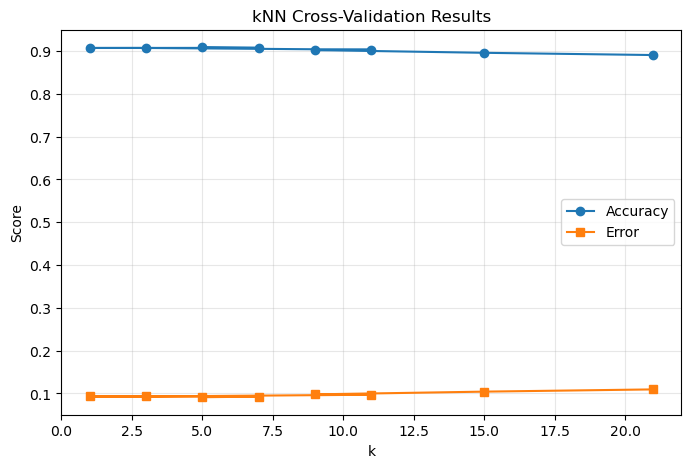

In [12]:
# 3.1 Plot validation accuracy and error for different k values
plt.figure(figsize=(8, 5))
plt.plot(knn_cv_df['k'], knn_cv_df['accuracy'], marker='o', label='Accuracy')
plt.plot(knn_cv_df['k'], knn_cv_df['error'], marker='s', label='Error')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('kNN Cross-Validation Results')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_cv.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# 3.2 Train Logistic Regression, LDA, and kNN with the best k
scaler_compare = StandardScaler()
X_train_scaled = scaler_compare.fit_transform(X_train)
X_test_scaled = scaler_compare.transform(X_test)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

knn_best = KNeighborsClassifier(n_neighbors=best_k, algorithm='kd_tree')
knn_best.fit(X_train_scaled, y_train)

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    return {
        'accuracy': acc,
        'error': 1 - acc,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0)
    }

results = []

for name, model in [('Logistic Regression', log_reg), ('LDA', lda), (f'kNN (k={best_k})', knn_best)]:
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    results.append({'model': name, 'dataset': 'train', **get_metrics(y_train, train_pred)})
    results.append({'model': name, 'dataset': 'test', **get_metrics(y_test, test_pred)})

results_df = pd.DataFrame(results)
display(results_df)


,model,dataset,accuracy,error,precision,recall
0,Logistic Regression,train,0.928986,0.071014,0.927803,0.888889
1,Logistic Regression,test,0.927889,0.072111,0.930394,0.883260
2,LDA,train,0.891014,0.108986,0.918298,0.793966
3,LDA,test,0.884448,0.115552,0.910486,0.784141
4,kNN (k=5),train,0.934493,0.065507,0.925620,0.906549
5,kNN (k=5),test,0.899218,0.100782,0.878924,0.863436


3.2 Logistic Regression preforms best due to its high accuracy, low error, and strong generalization, while LDA performs worst with the lowest accuracy and recall. kNN shows good performance but exhibits mild overfitting compated to Logistic Regression.

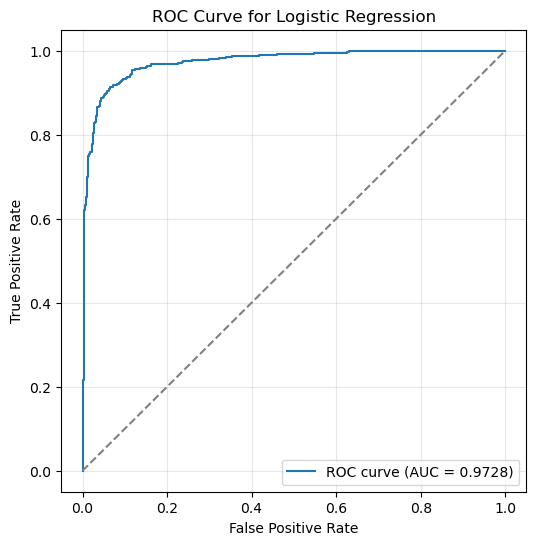

AUC: 0.9727529563453189


In [14]:
# 3.3 ROC curve and AUC for logistic regression using sklearn
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('AUC:', roc_auc)


In [15]:
# 3.4 Manual ROC curve using fixed thresholds
manual_thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
manual_points = []

for T in manual_thresholds:
    preds = (y_prob_lr >= T).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    tpr_value = tp / (tp + fn)
    fpr_value = fp / (fp + tn)
    manual_points.append({'threshold': T, 'fpr': fpr_value, 'tpr': tpr_value})

manual_roc_df = pd.DataFrame(manual_points)
display(manual_roc_df)


,threshold,fpr,tpr
0,0.0,1.000000,1.000000
1,0.1,0.307030,0.980176
2,0.2,0.167862,0.969163
3,0.3,0.098996,0.931718
4,0.4,0.065997,0.909692
5,0.5,0.043042,0.883260
6,0.6,0.034433,0.850220
7,0.7,0.027260,0.806167
8,0.8,0.015782,0.748899
9,0.9,0.004304,0.618943


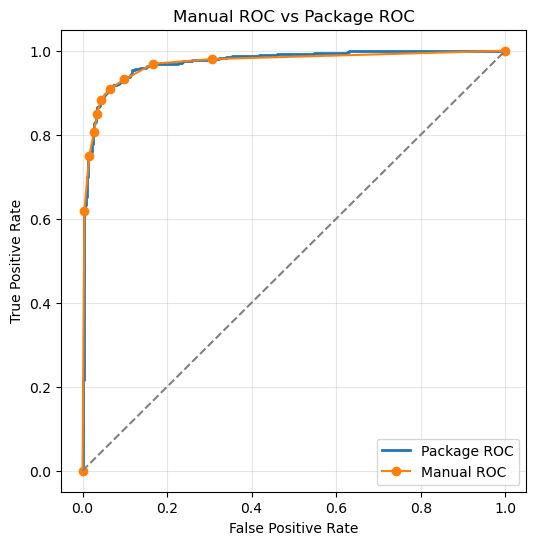

The manual ROC curve is less smooth because it only uses a small number of thresholds.
To make it more similar to the package ROC curve, use many more threshold values or all unique predicted probabilities.


In [16]:
# 3.4 Compare manual ROC with the package ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='Package ROC', linewidth=2)
plt.plot(manual_roc_df['fpr'], manual_roc_df['tpr'], marker='o', label='Manual ROC')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Manual ROC vs Package ROC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('The manual ROC curve is less smooth because it only uses a small number of thresholds.')
print('To make it more similar to the package ROC curve, use many more threshold values or all unique predicted probabilities.')


## Problem 4: Cross Validaton

In [17]:
def custom_k_fold_cv(X, y, model_name, k, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = np.arange(len(X))
    rng.shuffle(indices)
    folds = np.array_split(indices, k)
    fold_errors = []

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        if model_name == 'logistic':
            model = LogisticRegression(max_iter=5000)
        elif model_name == 'lda':
            model = LinearDiscriminantAnalysis()
        else:
            raise ValueError('Unknown model name')

        model.fit(X_train_fold_scaled, y_train_fold)
        val_pred = model.predict(X_val_fold_scaled)
        val_accuracy = accuracy_score(y_val_fold, val_pred)
        val_error = 1 - val_accuracy
        fold_errors.append(val_error)

    average_error = np.mean(fold_errors)
    return fold_errors, average_error


In [18]:
# 4.1
problem4_results = []

for k in [5, 10]:
    logistic_fold_errors, logistic_avg_error = custom_k_fold_cv(X, y, 'logistic', k)
    lda_fold_errors, lda_avg_error = custom_k_fold_cv(X, y, 'lda', k)

    problem4_results.append({
        'model': 'Logistic Regression',
        'k_folds': k,
        'fold_errors': logistic_fold_errors,
        'average_validation_error': logistic_avg_error
    })

    problem4_results.append({
        'model': 'LDA',
        'k_folds': k,
        'fold_errors': lda_fold_errors,
        'average_validation_error': lda_avg_error
    })

problem4_df = pd.DataFrame(problem4_results)
display(problem4_df)


,model,k_folds,fold_errors,average_validation_error
0,Logistic Regression,5,"[0.0684039087947883, 0.06739130434782614, 0.07...",0.076724
1,LDA,5,"[0.09771986970684043, 0.10543478260869565, 0.1...",0.113022
2,Logistic Regression,10,"[0.0585683297180043, 0.07826086956521738, 0.04...",0.073683
3,LDA,10,"[0.09327548806941433, 0.11304347826086958, 0.0...",0.114110


In [19]:
best_problem4_row = problem4_df.sort_values('average_validation_error').iloc[0]
print('Model with the lower average validation error performs better.')
print('Best result:')
print(best_problem4_row)

if best_problem4_row['model'] == 'Logistic Regression':
    print('\nLogistic Regression performed better than LDA in this run because it had the lower average validation error.')
else:
    print('\nLDA performed better than Logistic Regression in this run because it had the lower average validation error.')


Model with the lower average validation error performs better.
Best result:
model                                                     Logistic Regression
k_folds                                                                    10
fold_errors                 [0.0585683297180043, 0.07826086956521738, 0.04...
average_validation_error                                             0.073683
Name: 2, dtype: object

Logistic Regression performed better than LDA in this run because it had the lower average validation error.
